# RAM/CPU Analysis — DeepSeek TYPE_2

RAM+SWAP and CPU usage traces for the DeepSeek run (OLLAMA engine, TYPE_2, no fan).

- **Cell 1**: RAM+SWAP (MB) and CPU (%) plot with vertical phase lines (load, prefill, decode, end).
- **Cell 2**: Full version of the `02_hardware_timeline` notebook (temp, power, CPU/mem, throttling, swap).

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.transforms import RunCollection
from monitorviz.transforms.aggregations import hw_metrics_to_df
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_DIR = PROJECT_ROOT / "data" / "TFG-DATA" / "deepseek_type2"

assert DATA_DIR.is_dir(), f"Not found: {DATA_DIR.resolve()}"

coll = load_collection(DATA_DIR)
hw_runs = RunCollection(runs=[r for r in coll if r.has_hardware_data])

print(f"Runs loaded: {len(coll)} total, {len(hw_runs)} with hardware data.")
for r in hw_runs:
    print(f"  • {r.model_short} ({r.summary.inference_engine}) — "
          f"{len(r.hw_samples)} hw samples, {len(r.prompts)} prompts")

Runs loaded: 1 total, 1 with hardware data.
  • deepseek:q4_k_m (OLLAMA) — 512 hw samples, 1 prompts


## RAM + SWAP and CPU with phase lines
Based on the old version of the visualizer
Left axis (red): RAM + SWAP used in MB.  
Right axis (blue): CPU usage in %.  
Vertical lines:
- 🟢 Dashed green: start of prompt (start_timestamp)
- 🟠 Dashed orange: end of model load (load_duration)
- 🟣 Dashed purple: end of prefill (prompt_eval_duration)
- 🟤 Dashed brown: end of decode (eval_duration)

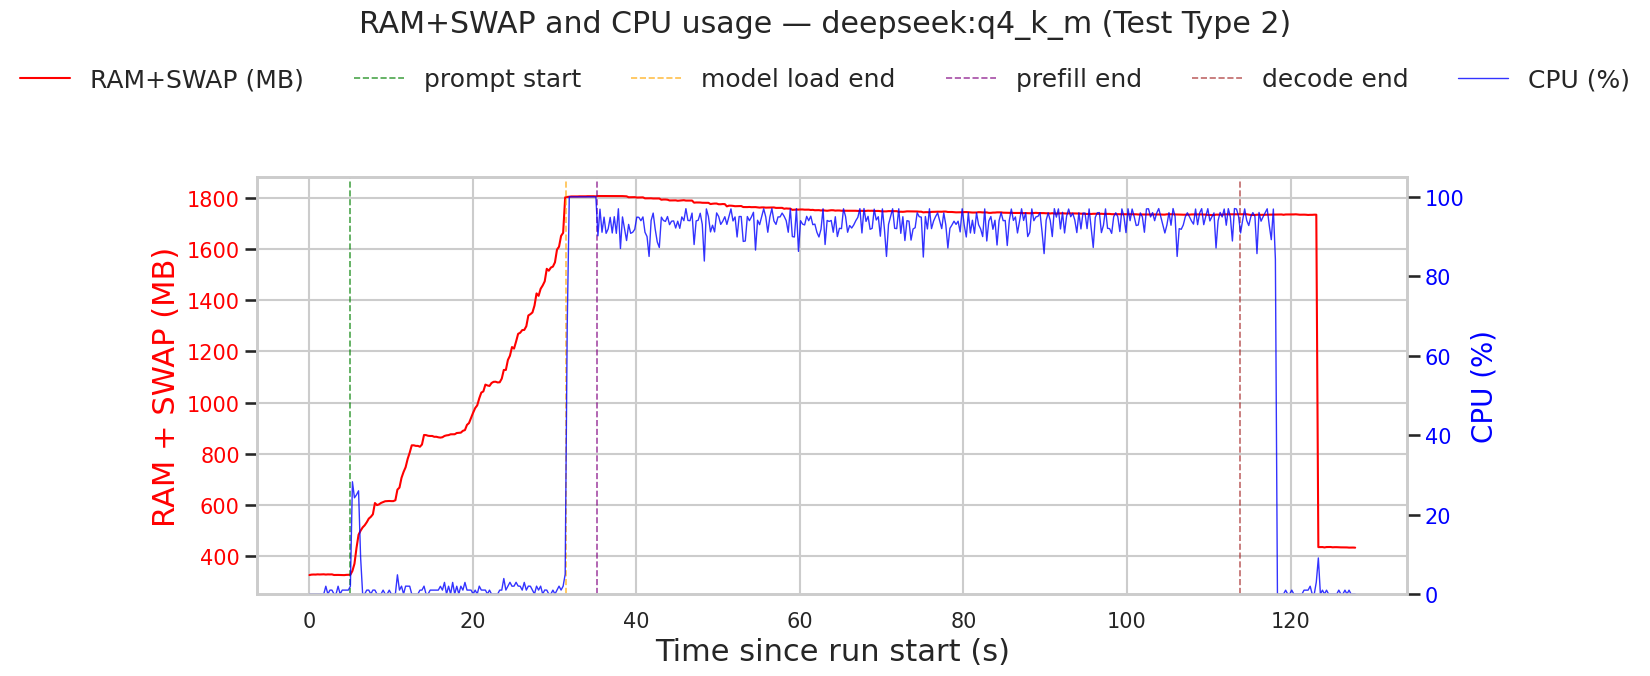

In [2]:
def plot_ram_cpu(run):
    """RAM+SWAP (MB) and CPU (%) over the run with vertical phase lines."""
    hw_df = hw_metrics_to_df(run)

    if hw_df.empty:
        print(f"No hardware data for {run.model_short}")
        return

    hw_df = hw_df[hw_df["temperature_c"] != -1]
    if hw_df.empty:
        print(f"No valid samples for {run.model_short}")
        return

    ram_swap_mb = (hw_df["mem_used_bytes"] + hw_df["swap_used_bytes"]) / 1_000_000

    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.set_xlabel("Time since run start (s)", fontsize=22)
    ax1.set_ylabel("RAM + SWAP (MB)", color="red", fontsize=22)
    ax1.plot(hw_df["t_rel_s"], ram_swap_mb, color="red", lw=1.5, label="RAM+SWAP (MB)")
    ax1.tick_params(axis="y", labelcolor="red")

    ax2 = ax1.twinx()
    ax2.set_ylabel("CPU (%)", color="blue", fontsize=20)
    ax2.plot(hw_df["t_rel_s"], hw_df["cpu_usage_pct"], color="blue", lw=1.0, alpha=0.8, label="CPU (%)")
    ax2.tick_params(axis="y", labelcolor="blue")
    ax2.set_ylim(0, 105)
    ax2.grid(False)

    run_start_ns = run.summary.timestamp_run_start_ns
    first = True
    for p in run.prompts:
        if p.is_empty_generation:
            continue
        load_start_s    = (p.start_timestamp_ns - run_start_ns) / 1e9
        prefill_start_s = load_start_s + p.load_duration_ns / 1e9
        decode_start_s  = prefill_start_s + p.prompt_eval_duration_ns / 1e9
        decode_end_s    = decode_start_s + p.eval_duration_ns / 1e9

        ax1.axvline(load_start_s,    color="green",  ls="--", lw=1.2, alpha=0.7,
                    label="prompt start"    if first else None)
        ax1.axvline(prefill_start_s, color="orange", ls="--", lw=1.2, alpha=0.7,
                    label="model load end" if first else None)
        ax1.axvline(decode_start_s,  color="purple", ls="--", lw=1.2, alpha=0.7,
                    label="prefill end"      if first else None)
        ax1.axvline(decode_end_s,    color="brown",  ls="--", lw=1.2, alpha=0.7,
                    label="decode end"       if first else None)
        first = False

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    fig.legend(lines1 + lines2, labels1 + labels2,
               loc="upper center", ncol=6, fontsize=18,
               bbox_to_anchor=(0.5, 1.08))

    fig.suptitle(
        f"RAM+SWAP and CPU usage — {run.model_short} (Test Type 2)",
        y=1.14,
    )

    fig.tight_layout()
    plt.show()


for r in hw_runs.runs:
    plot_ram_cpu(r)

## Full hardware timeline (notebook 02 version)

For each run: temperature + frequency, RAM/CPU with phases, and hw metric histograms.

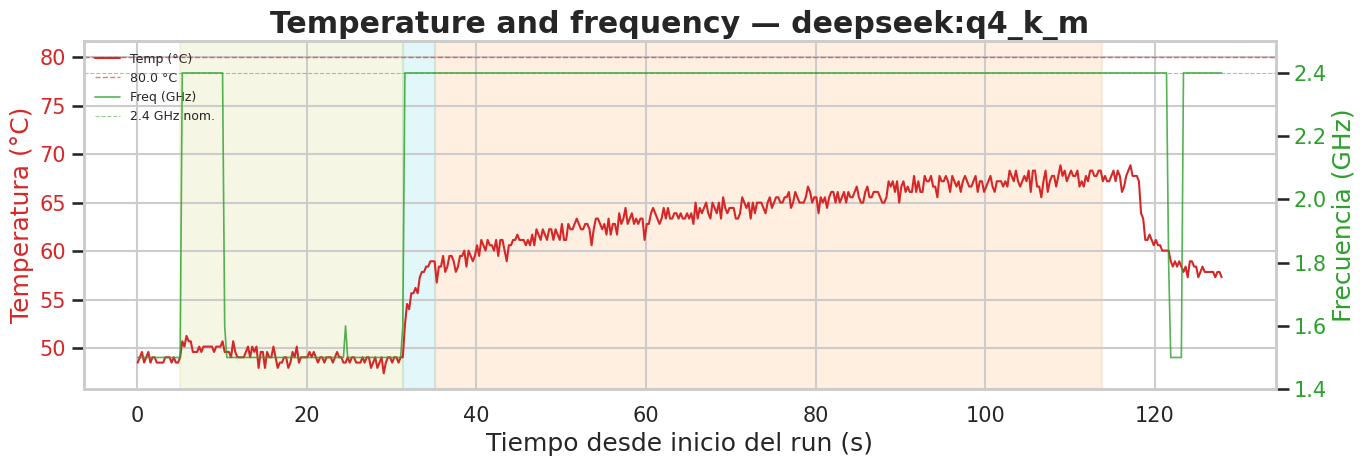

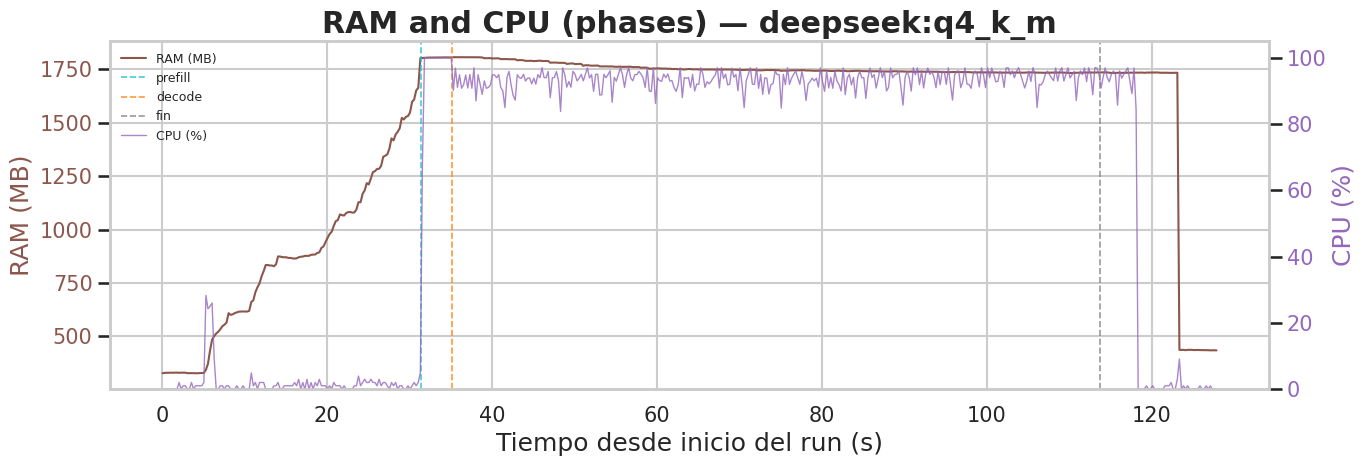

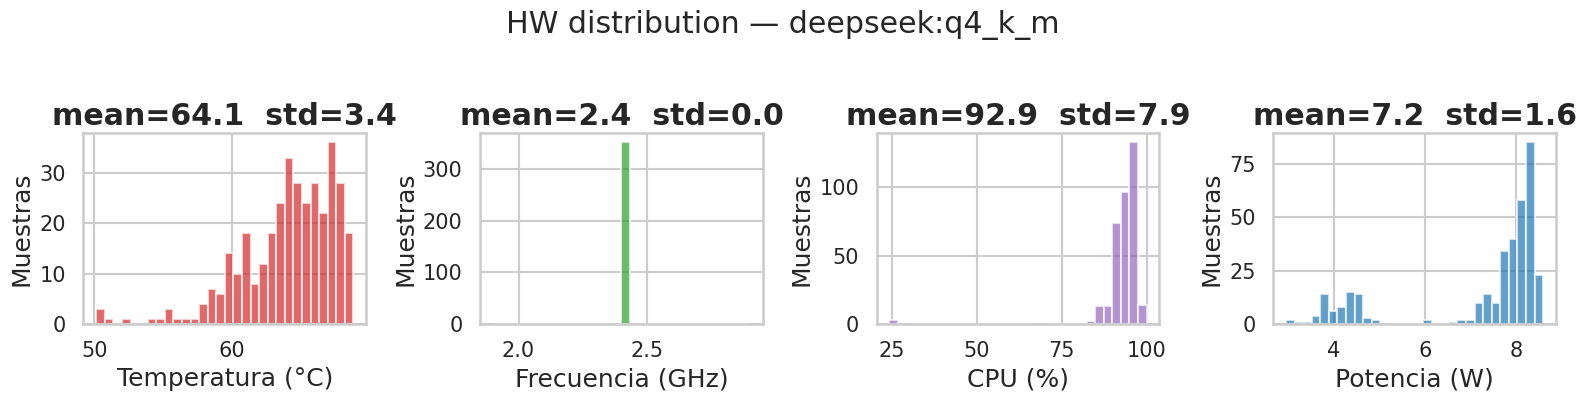

In [3]:
from monitorviz.viz import cpu_memory_dual_phases, hw_distributions_panel, temp_freq_dual

hw_df = hw_runs.hw_metrics_df()

for r in hw_runs.runs:
    hw_r = hw_df[hw_df["run_id"] == r.run_id]
    if hw_r.empty:
        continue

    fig = temp_freq_dual(hw_r, r, title=f"Temperature and frequency — {r.model_short}")
    plt.show()

    fig = cpu_memory_dual_phases(hw_r, r, title=f"RAM and CPU (phases) — {r.model_short}")
    plt.show()

    fig = hw_distributions_panel(hw_r, r, title=f"HW distribution — {r.model_short}")
    plt.show()